# **AIN 214 - PA2 - FALL 2025**

**Student Number** : 2230765032

**Name Surname**   : Baki Umut Gündüz


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 24.11.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

# **Necessary Imports**

In [19]:
# Import required python modules
import pandas as pd
import sqlite3

# **PART- 1**

**Superstore Sales Management System (50 Points)**



For this part, you will use a dataset from a Superstore retail company. The dataset includes comprehensive information about customers, products, orders, and sales operations across different regions in the United States.

**Dataset Entities**

* **Customers**: The system contains detailed customer profiles including customer ID, name, and segment information (Consumer, Corporate, Home Office). Understanding customer demographics and purchasing behavior is essential for targeted marketing and customer relationship management.

* **Products**: A comprehensive catalog of all products sold by the superstore. Each product record includes a unique product ID, product name, category (Furniture, Office Supplies, Technology), and sub-category. This information is crucial for inventory management, product performance analysis, and strategic planning.

* **Locations**: Geographic information about where customers are located and where orders are shipped. Includes city, state, postal code, region (Central, East, South, West), and country. This data enables regional sales analysis and helps optimize distribution and shipping strategies.

* **Orders**: Tracks all purchase transactions made by customers. Each order contains the order date, ship date, shipping mode (Standard Class, Second Class, First Class, Same Day), and links to customer and location information. This serves as the foundation for analyzing sales trends, shipping efficiency, and customer purchasing patterns.

* **Order Details**:  Detailed line items for each order, recording which products were purchased, quantity, sales amount, discount applied, and profit generated. This granular data is essential for profitability analysis, discount impact assessment, and understanding product performance at the transaction level.


This dataset will be used to design a normalized relational database for managing retail operations. Your task is to build an efficient database schema, establish proper relationships between tables, and write SQL queries to extract meaningful business insights.


**Dataset Columns**

* **Row ID**: Unique identifier for each row in the dataset (sequential number)
* **Order ID**: Unique identifier for each order (format: XX-YYYY-NNNNNN). Multiple rows can have the same Order ID if the order contains multiple products
* **Order Date**: Date when the order was placed by the customer (format: MM/DD/YYYY)
* **Ship Date**: Date when the order was shipped to the customer (format: MM/DD/YYYY)
* **Ship Mode**: Shipping method selected for the order (Standard Class, Second Class, First Class, Same Day)
* **Customer ID**: Unique identifier for each customer (format: XX-NNNNN)
* **Customer Name**: Full name of the customer who placed the order
* **Segment**: Customer segment classification (Consumer, Corporate, Home Office)
* **Country**: Country where the customer is located (all orders are from United States)
* **City**: City name where the order is being shipped
* **State**: US state where the order is being shipped (2-letter state code)
* **Postal Code**: ZIP code of the delivery location (5-digit postal code)
* **Region**: Geographic region classification (Central, East, South, West)
* **Product ID**: Unique identifier for each product (format: XXX-XX-NNNNNNN)
* **Category**: High-level product category (Furniture, Office Supplies, Technology)
* **Sub-Category**: Detailed product classification within the category (e.g., Chairs, Phones, Binders)
* **Product Name**: Full descriptive name of the product
* **Sales**: Revenue generated from the product sale in US Dollars ($)
* **Quantity**: Number of units of the product purchased in the order
* **Discount**: Discount rate applied to the product (decimal value between 0 and 1, where 0.2 = 20% discount)
* **Profit**: Profit earned from the sale after deducting costs and discounts in US Dollars ($). Can be negative if the sale resulted in a loss

---


**Dataset Path:** "Data/Sample - Superstore.csv"
  
---

**Technical Requirements**
* **Databas**: Use sqlite3 Python package for in-memory database management
* **Libraries**: Use pandas for data manipulation

**Note** You can use either pandas or sqlite3 for query execution.

---
**Notes on Database Implementation**

All database operations should be performed in-memory using SQLite. This means:
* Database exists only during program execution
* No persistent file is created
* Fast performance for analysis tasks
* Connection should remain open throughout all questions

---

### Q1. Design your schema as tables. Draw the necessary tables with the appropriate attributes. State the primary keys, foreign keys (and their references). Create the tables in your schema in the database(10pts).

Your database design here
---
---
***Example Table***:


| Column   | Type  | Key      | Description                              |
|----------|-------|----------|------------------------------------------|
| ID       | INTEGER| PK      | Unique identifier table1                 |
| ID2      | INTEGER| FK      | identifier table2                        |
| Name     | TEXT   |         | patient name                             |
| FOREIGN KEY (ID2) REFERENCES table2(ID2)     |    |          |         |

***Customers***:

| Column                                                      | Type    | Key | Description                           |
| ----------------------------------------------------------- | ------- | --- | ------------------------------------- |
| Customer_ID                                                 | TEXT    | PK  | Unique identifier for each customer   |
| Customer_Name                                               | TEXT    |     | Full name of the customer             |
| Segment                                                     | TEXT    |     | Customer segment                      |
| Location_ID                                                 | INTEGER | FK  | Identifier of the customer’s location |
| FOREIGN KEY (Location_ID) REFERENCES Locations(Location_ID) |         |     |                                       |


***Products***:

| Column       | Type | Key | Description                        |
| ------------ | ---- | --- | ---------------------------------- |
| Product_ID   | TEXT | PK  | Unique identifier for each product |
| Product_Name | TEXT |     | Product name                       |
| Category     | TEXT |     | Product category                   |
| Sub_Category | TEXT |     | Product sub-category               |


***Locations***:

| Column      | Type    | Key | Description                         |
| ----------- | ------- | --- | ----------------------------------- |
| Location_ID | INTEGER | PK  | Unique identifier for each location |
| Country     | TEXT    |     | Country name                        |
| City        | TEXT    |     | City name                           |
| State       | TEXT    |     | State / province                    |
| Postal_Code | INTEGER |     | Postal code                         |
| Region      | TEXT    |     | Sales region                        |


***Orders***:

| Column                                                      | Type | Key | Description                      |
| ----------------------------------------------------------- | ---- | --- | -------------------------------- |
| Order_ID                                                    | TEXT | PK  | Unique identifier for each order |
| Customer_ID                                                 | TEXT | FK  | Customer who placed the order    |
| Order_Date                                                  | TEXT |     | Date when the order was placed   |
| Ship_Date                                                   | TEXT |     | Date when the order was shipped  |
| Ship_Mode                                                   | TEXT |     | Shipping method                  |
| FOREIGN KEY (Customer_ID) REFERENCES Customers(Customer_ID) |      |     |                                  |


***Order Details***:

| Column                                                   | Type    | Key | Description                          |
| -------------------------------------------------------- | ------- | --- | ------------------------------------ |
| Order_Detail_ID                                          | INTEGER | PK  | Unique identifier for each line item |
| Order_ID                                                 | TEXT    | FK  | Related order identifier             |
| Product_ID                                               | TEXT    | FK  | Related product identifier           |
| Sales                                                    | REAL    |     | Sales amount                         |
| Quantity                                                 | INTEGER |     | Quantity sold                        |
| Discount                                                 | REAL    |     | Discount applied                     |
| Profit                                                   | REAL    |     | Profit from the line item            |
| FOREIGN KEY (Order_ID) REFERENCES Orders(Order_ID)       |         |     |                                      |
| FOREIGN KEY (Product_ID) REFERENCES Products(Product_ID) |         |     |                                      |


In [20]:
# code implementation
df = pd.read_csv("Data/Sample - Superstore.csv", encoding="latin1")

df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")

conn = sqlite3.connect(":memory:")

conn.executescript("""
DROP TABLE IF EXISTS Customers;
DROP TABLE IF EXISTS Products;
DROP TABLE IF EXISTS Locations;
DROP TABLE IF EXISTS Orders;
DROP TABLE IF EXISTS Order_Details;

CREATE TABLE Customers (
        Customer_ID TEXT PRIMARY KEY,
        Customer_Name TEXT,
        Segment TEXT,
        Location_ID INTEGER,
        FOREIGN KEY (Location_ID) REFERENCES Locations(Location_ID)
);

CREATE TABLE Products ( 
        Product_ID TEXT PRIMARY KEY,
        Product_Name TEXT,
        Category TEXT,
        Sub_Category TEXT
);

CREATE TABLE Locations (
        Location_ID INTEGER PRIMARY KEY,
        Country TEXT,
        City TEXT,
        State TEXT,
        Postal_Code INTEGER,
        Region TEXT
);

CREATE TABLE Orders(
        Order_ID TEXT PRIMARY KEY,
        Customer_ID TEXT,
        Order_Date TEXT,
        Ship_Date TEXT,
        Ship_Mode TEXT,
        FOREIGN KEY (Customer_ID) REFERENCES Customers(Customer_ID)
);

CREATE TABLE Order_Details(
        Order_Detail_ID INTEGER PRIMARY KEY,
        Order_ID TEXT,
        Product_ID TEXT,
        Sales REAL,
        Quantity INTEGER,
        Discount REAL,
        Profit REAL,
        FOREIGN KEY (Order_ID) REFERENCES Orders(Order_ID),
        FOREIGN KEY (Product_ID) REFERENCES Products(Product_ID)
);
""")

df_locations = df[["Country", "City", "State", "Postal_Code", "Region"]].drop_duplicates()
df_locations["Location_ID"] = range(1, len(df_locations) + 1)
df_locations = df_locations[["Location_ID", "Country", "City", "State", "Postal_Code", "Region"]]

df_customers = df[["Customer_ID", "Customer_Name", "Segment", "Country", "City", "State", "Postal_Code", "Region"]].drop_duplicates(subset=["Customer_ID"])
df_customers = df_customers.merge(df_locations, on=["Country", "City", "State", "Postal_Code", "Region"], how="left")
df_customers = df_customers[["Customer_ID", "Customer_Name", "Segment", "Location_ID"]]

df_products = df[["Product_ID", "Product_Name", "Category", "Sub_Category"]].drop_duplicates(subset="Product_ID")

df_orders = df[["Order_ID", "Customer_ID", "Order_Date", "Ship_Date", "Ship_Mode"]].drop_duplicates(subset=["Order_ID"])

df_order_details = df[["Order_ID", "Product_ID", "Sales", "Quantity", "Discount", "Profit"]].copy()
df_order_details["Order_Detail_ID"] = range(1, len(df_order_details) + 1)
df_order_details = df_order_details[["Order_Detail_ID", "Order_ID", "Product_ID", "Sales", "Quantity", "Discount", "Profit"]]

df_locations.to_sql("Locations", conn, if_exists="replace", index=False)
df_customers.to_sql("Customers", conn, if_exists="replace", index=False)
df_products.to_sql("Products", conn, if_exists="replace", index=False)
df_orders.to_sql("Orders", conn, if_exists="replace", index=False)
df_order_details.to_sql("Order_Details", conn, if_exists="replace", index=False);


### Q2. Write a SQL query to identify the top 10 products by total profit(10pts).

The result should include:

* **Product ID**
* **Product Name**
* **Category**
* **Sub-category**
* **Total Number of Sales**
* **Total Profit**
* **Profit Margin**

**Hint**: profit_margin = (total_profit/total_sales)

In [21]:
# Implementation here
query = """
SELECT P.Product_ID, P.Product_Name, P.Category, P.Sub_Category, COUNT(O.Sales) AS Total_Number_Sales, SUM(O.Profit) AS Total_Profit, SUM(O.Profit)/SUM(O.Sales) AS Profit_Margin 
FROM Products AS P
JOIN Order_Details as O On O.Product_ID = P.Product_ID
GROUP BY P.Product_ID, P.Product_Name, P.Category, P.Sub_Category
ORDER BY Total_Profit DESC
LIMIT 10;
"""

df_result = pd.read_sql_query(query, conn)
print(df_result)

        Product_ID                                       Product_Name  \
0  TEC-CO-10004722              Canon imageCLASS 2200 Advanced Copier   
1  OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...   
2  TEC-CO-10001449               Hewlett Packard LaserJet 3310 Copier   
3  TEC-CO-10003763                 Canon PC1060 Personal Laser Copier   
4  TEC-AC-10002049          Logitech G19 Programmable Gaming Keyboard   
5  TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer ...   
6  TEC-MA-10003979                  Ativa V4110MDD Micro-Cut Shredder   
7  TEC-MA-10001047   3D Systems Cube Printer, 2nd Generation, Magenta   
8  OFF-BI-10001120               Ibico EPK-21 Electric Binding System   
9  TEC-MA-10000045                  Zebra ZM400 Thermal Label Printer   

          Category Sub_Category  Total_Number_Sales  Total_Profit  \
0       Technology      Copiers                   5    25199.9280   
1  Office Supplies      Binders                  10     77

### Q3. Analyze customer purchasing patterns across different segments(10pts). ,

Create a query that shows:

* **Segment**
* **Number of Customers**
* **Total Orders**
* **Total Sales**
* **Total Profit**
* **Average Order Value**
* **Average Profit per Customer**

Compare the three segments (Consumer, Corporate, Home Office). Which segment is most profitable?

**Hint**:

average_order_value = (total_sales/total_orders)
average_profit_per_customer = (total_profit/distinct_customer_count)

In [22]:
# implementation here
query = """
SELECT C.Segment, COUNT(DISTINCT C.Customer_ID) AS Number_Of_Customers, COUNT(DISTINCT O.Order_ID) AS Total_Orders, SUM(OD.Sales) AS Total_Sales, SUM(OD.Profit) AS Total_Profit, 
        SUM(OD.Sales)/COUNT(DISTINCT O.Order_ID) AS Average_Order_Value, SUM(OD.Profit)/COUNT(DISTINCT C.Customer_ID) AS Average_Profit_Per_Customer
FROM Customers AS C
JOIN Orders AS O ON C.Customer_ID = O.Customer_ID
JOIN Order_Details AS OD ON O.Order_ID = OD.Order_ID
GROUP BY C.Segment 
ORDER BY Total_Profit DESC
"""

df_result = pd.read_sql_query(query, conn)
print(df_result)


       Segment  Number_Of_Customers  Total_Orders   Total_Sales  Total_Profit  \
0     Consumer                  409          2586  1.161401e+06   134119.2092   
1    Corporate                  236          1514  7.061464e+05    91979.1340   
2  Home Office                  148           909  4.296531e+05    60298.6785   

   Average_Order_Value  Average_Profit_Per_Customer  
0           449.111116                   327.919827  
1           466.411075                   389.742093  
2           472.665730                   407.423503  


The Consumer segment has the highest total sales and total profit.
But if we look at profit per customer, Home Office and Corporate are slightly higher.

### Q4. Write a SQL query to analyze sales performance across different regions and categories(10pts).

The result should include:

* **Region**
* **Category**
* **Total sales**
* **Total Profit**
* **Total Quantity Sold**
* **Average Discount**

Group by both region and category. Order by region and total sales.
Identify which category performs best in each region.

In [23]:
# implementation here
query = """
SELECT L.Region, P.Category, SUM(OD.Sales) AS Total_Sales, SUM(OD.Profit) AS Total_Profit,
     SUM(OD.Quantity) AS Total_Quantity_Sold, AVG(OD.Discount) AS Average_Dİscount 
FROM Locations AS L
JOIN Customers AS C ON C.Location_ID = L.Location_ID
JOIN Orders AS O ON O.Customer_ID = C.Customer_ID
JOIN Order_Details AS OD ON OD.Order_ID = O.Order_ID
JOIN Products AS P ON P.Product_ID = OD.Product_ID
GROUP BY L.Region, P.Category
ORDER BY L.Region, Total_Sales DESC
"""

df_result = pd.read_sql_query(query, conn)
print(df_result)

     Region         Category  Total_Sales  Total_Profit  Total_Quantity_Sold  \
0   Central       Technology  184752.7770    30565.1789                 1709   
1   Central        Furniture  176419.4072     4026.2656                 1836   
2   Central  Office Supplies  157627.9480    29017.9045                 5420   
3      East       Technology  246022.2590    58586.5005                 1910   
4      East  Office Supplies  193251.3320    33732.2481                 6496   
5      East        Furniture  172460.7085     2285.5635                 2109   
6     South       Technology  160094.5890    10954.9662                 1081   
7     South  Office Supplies  128092.6880    14414.5690                 3712   
8     South        Furniture  113844.7063     4805.6005                 1328   
9      West        Furniture  279274.9733     7333.8432                 2755   
10     West       Technology  245284.4080    45348.3025                 2239   
11     West  Office Supplies  240075.064

Technology is the top category in 3 regions,
but in the West region, Furniture is number one.

### Q5. Find which products are frequently bought together in the same order(10pts).

**Requirements**:

* Identify top 10 product pairs that appear in the same orders most frequently
* Show: product_1, product_2, times_bought_together, total_revenue_from_pair
* Exclude pairs where product_1 = product_2

**Hint**

Self-join Order_Details on order_id where product_id differs

In [24]:
# implementation here
query = """
SELECT OD1.Product_ID AS Product_1, OD2.Product_ID AS Product_2, COUNT(DISTINCT OD1.Order_ID) AS times_bought_together, SUM(OD1.Sales + OD2.Sales) AS total_revenue_from_pair
FROM Order_Details AS OD1
JOIN Order_Details AS OD2 ON OD1.Order_ID = OD2.Order_ID AND OD1.Product_ID < OD2.Product_ID
GROUP BY Product_1, Product_2
ORDER BY times_bought_together DESC, total_revenue_from_pair DESC
LIMIT 10;
"""

df_result = pd.read_sql_query(query, conn)
print(df_result)

         Product_1        Product_2  times_bought_together  \
0  OFF-ST-10001558  TEC-CO-10004722                      2   
1  FUR-TA-10002645  TEC-AC-10003033                      2   
2  FUR-TA-10003569  TEC-PH-10003187                      2   
3  FUR-FU-10003832  OFF-BI-10001359                      2   
4  FUR-BO-10002213  OFF-LA-10002762                      2   
5  TEC-AC-10002049  TEC-PH-10000702                      2   
6  FUR-CH-10003379  TEC-PH-10003885                      2   
7  TEC-AC-10002049  TEC-AC-10003628                      2   
8  OFF-ST-10002554  TEC-AC-10002637                      2   
9  FUR-TA-10001039  TEC-PH-10004447                      2   

   total_revenue_from_pair  
0                31564.870  
1                 4655.690  
2                 3780.970  
3                 3307.956  
4                 2968.378  
5                 2891.622  
6                 2533.290  
7                 2149.740  
8                 1772.116  
9                 1097.634 

# **Part 2. Data Analysis and Visualization(50pts)**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In this part, you'll explore and visualize data from the Netflix Movies and TV Shouws Dataset.
Your goal is to get insights about Netflix's contents and trends. What types of shows are most common,
how the Netflix content has evolved, and how content varies across countries and genres.

You will perform **data manipulation** and **visualization** using Python (`pandas`, `numpy`, `matplotlib`).

**Your answers should include code, charts and written interpretation.**

## Dataset

The dataset we use in this part is **"Netflix Movies and TV Shows"**.

Columns include:
`show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`, `month_added`, `month_name_added`, `year_added`

Start working by importing the dataset into a pandas DataFrame.

In [26]:
# implementation here
df = pd.read_csv("Data/netflix_titles.csv")

### Q1. Content Type Analysis(5pts)

- What proportion of titles on Netflix are Movies vs TV Shows?

Start by examining how many records belong to each type. Visualize the distribution (e.g. pie chart) and report which category dominates the Netflix library.

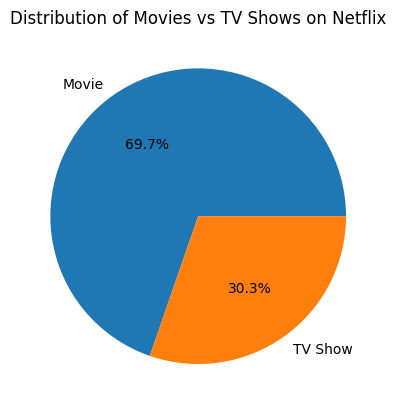

In [27]:
# implementation here
counts = df["type"].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.show()

It extracts whether each title is a Movie or a TV Show, counts how many of each type exist, and visualizes this distribution with a simple pie chart, giving a clear overview of the platform’s content composition.

### Q2. Time Trends(5pts)

- How has the number of titles added to Netflix changed over time?

Use the release time information from the dataset and count how many titles were added each year. Visualize the trend with a plot to show how Netflix's catalog has grown over time.

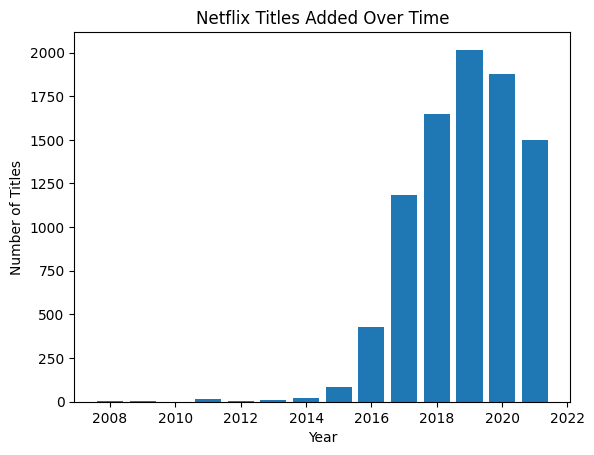

In [28]:
# implementation here
counts = df["year_added"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Titles Added Over Time")
plt.show()

It examines how the amount of content added to Netflix changes over time by using the year_added column from the dataset and visualizes this trend with a bar plot.

### Q3. Genre Analysis(5pts)

- What are the 10 most common genres on Netflix?

The `listed_in` column contains the genre information. But it can contain multiple genres, seperated by commas. Split these into individual genre values and count how often each one appears. Plot the top 10 genres in a chart and describe the plot in 1-2 sentences.

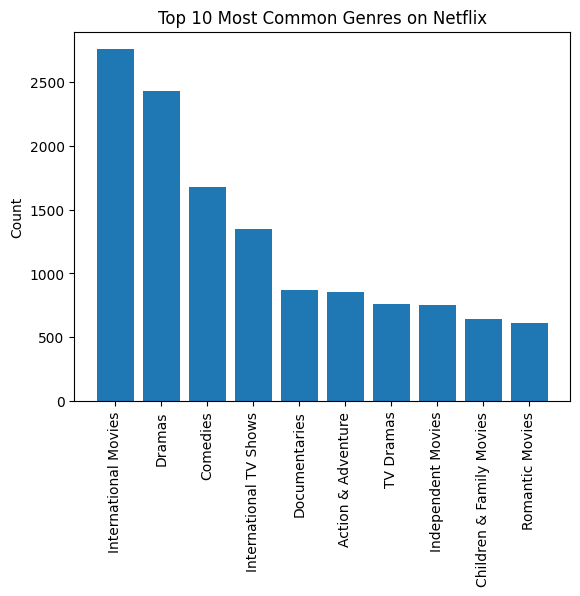

In [29]:
# implementation here
counts = df["listed_in"].str.split(",").explode().str.strip().value_counts().head(10)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Top 10 Most Common Genres on Netflix")
plt.show()

It analyzes genre popularity by using the listed_in column, splitting titles with multiple genres and counting each genre separately, and shows that International Movies and Dramas are the most common genres—indicating Netflix’s strong global variety—while Comedies and Documentaries also rank high, reflecting the platform’s overall diversity.

### Q4. Geographic Patterns(5pts)

- Which 10 countries have produced the most Netflix titles?

Some titles are produced by multiple countries (e.g., "France, Germany"). Ensure you account for all countries evenly by splitting the entries before counting. Show the top contributors using a chart.

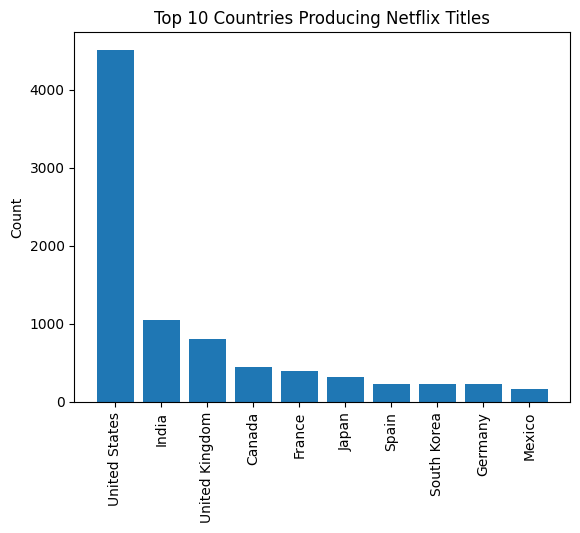

In [30]:
# implementation here
top_10 = df["country"].str.split(",").explode().str.strip().value_counts().head(10)
plt.bar(top_10.index, top_10.values)
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Top 10 Countries Producing Netflix Titles")
plt.show()

It analyzes the geographic distribution of Netflix content by using the country column, splitting entries that list multiple countries, and counting each country individually to show which regions contribute the most titles.

### Q5. Titles Added per Month(5pts)

- How many titles are added to Netflix in each month?

Use the release time information from the dataset. And report the added titles by "Month-Year" (e.g. "June-2016) then present it by a chart. You will manipulate the data to get that information. Then describe&comment on the chart with 1-2 sentences.

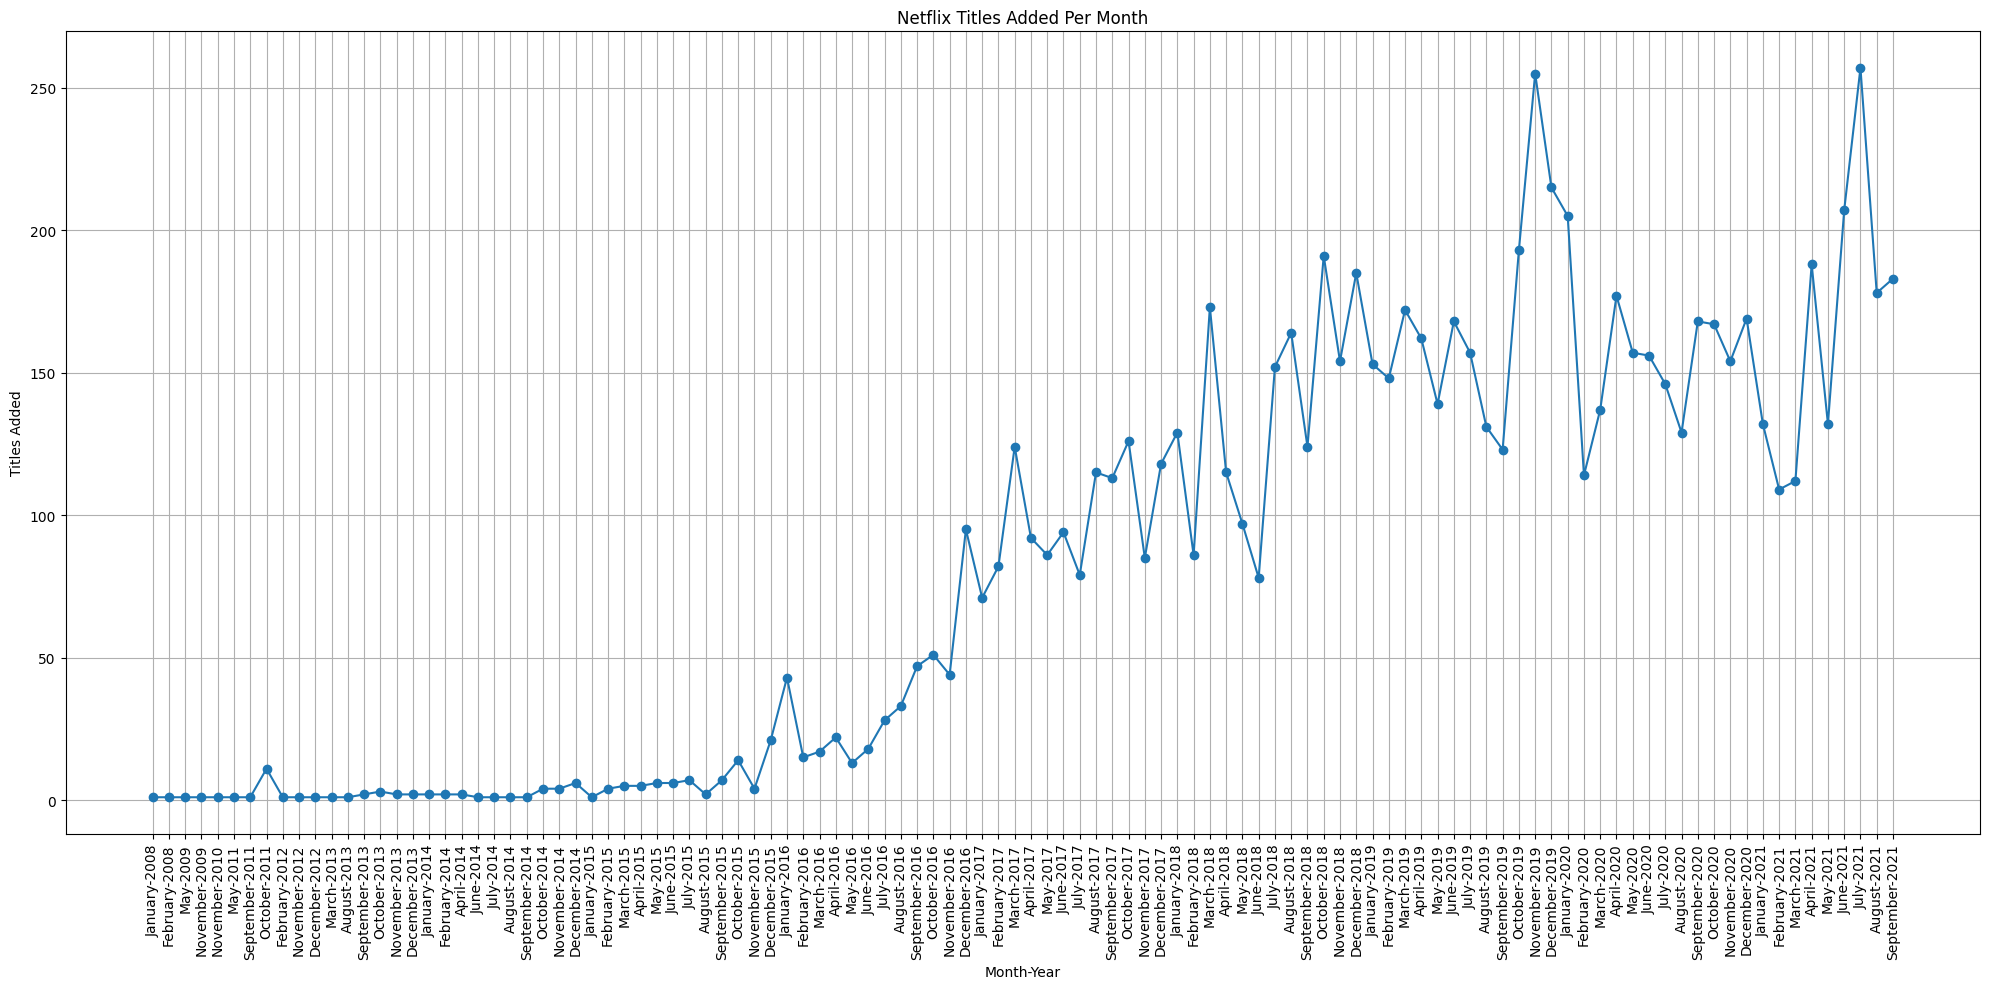

In [31]:
# implementation here
dates = pd.to_datetime(df["date_added"], errors="coerce")
periods = dates.dt.to_period("M")
counts = periods.value_counts().sort_index()
labels = counts.index.to_timestamp().strftime("%B-%Y")

plt.figure(figsize=(20, 10))
plt.plot(counts.values, marker="o")
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=10)
plt.xlabel("Month-Year")
plt.ylabel("Titles Added")
plt.title("Netflix Titles Added Per Month")
plt.tight_layout()
plt.grid(True)
plt.show()

It uses the date-added information to extract the month and year for each title, creates a time-series of how many items were added over time, and shows that monthly additions fluctuate—with some months spiking due to licensing or seasonal releases—while overall exhibiting a slight upward growth trend.

### Q6. Country Contribution Over Time(10pts)

- Identify the top 10 content producing countries.
- For the top 5 producing countries, how has the number of titles added changed year by year?

Identify the top 10 countries by counting total contents. Plot the results. Then identify the 5 countries with the most titles overall, and filter the dataset to just those. Group by both year added and country, and plot separate lines to compare their trends over time. Visualize the result and describe&comment on the chart with 1-2 sentences.

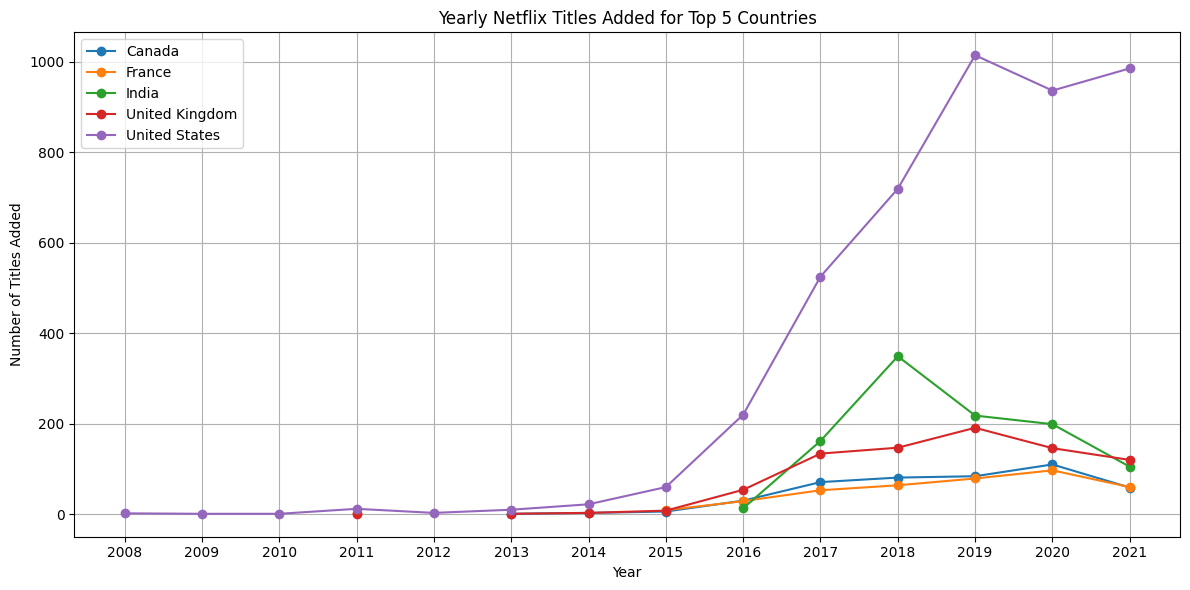

In [32]:
# implementation here
top_5_countries = top_10.head(5).index

tmp = df.copy()
tmp["country_exp"] = tmp["country"].str.split(",")
tmp = tmp.explode("country_exp")
tmp["country_exp"] = tmp["country_exp"].str.strip()
tmp["year_added"] = pd.to_datetime(tmp["date_added"], errors="coerce").dt.year


top5_year = (
    tmp[tmp["country_exp"].isin(top_5_countries)]
    .groupby(["year_added", "country_exp"])
    .size()
    .unstack("country_exp")
    .sort_index()
)

plt.figure(figsize=(12, 6))
for c in top5_year.columns:
    plt.plot(top5_year.index, top5_year[c], marker="o", label=c)

plt.xticks(top5_year.index)
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.title("Yearly Netflix Titles Added for Top 5 Countries")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It continues the country-based analysis by taking the top five content-producing countries from Q4 and examining how their yearly contributions change, showing that the United States consistently adds the most titles while India and the United Kingdom grow in certain years and other countries vary more, highlighting Netflix’s reliance on a few major producers.

### Q7. Average Movie Duration Over Time(5pts)

- How has the average movie duration changed over the years?

Focus only movies on the dataset (ignore TV Shows). Convert the duration column to a numeric value. And group by release year to compute the average movie length per year and visualize the trend.
Describe the chart with 1-2 sentences.

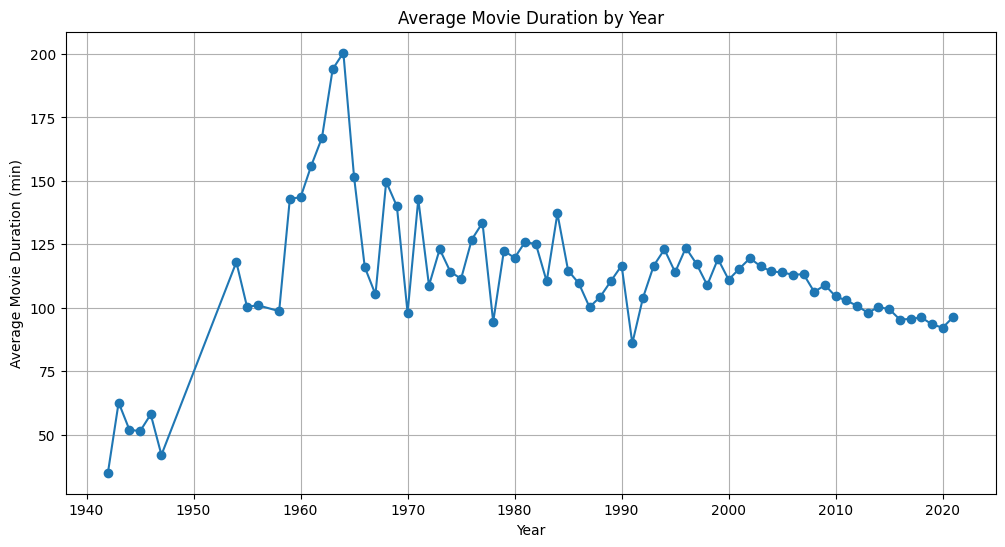

In [33]:
# implementation here
counts = df[df["type"] == "Movie"].copy()
counts["duration"] = counts["duration"].str.split().str[0].astype(int)
avg_duration_by_year = counts.groupby("release_year")["duration"].mean().round(2)

plt.figure(figsize=(12, 6))
plt.plot(avg_duration_by_year.index, avg_duration_by_year.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average Movie Duration (min)")
plt.title("Average Movie Duration by Year")
plt.grid(True)
plt.show()

It analyzes how movie duration changes over the years by using the duration information for movies only, calculating the average length for each year and examining whether Netflix’s movie runtimes show growth, decline, or stability over time.

### Q8. TV Shows - Average Number of Seasons per Country(5pts)

- For each country, what is the average number of seasons in its TV Shows?

Focus only TV Shows on the dataset. The duration column contains the number of seasons (e.g. "3 Seasons"). Parse this information to a usable format. Then compute the average per country and visualize the top 10 countries. This gives insight about the countries tends to produce longer-running TV series.

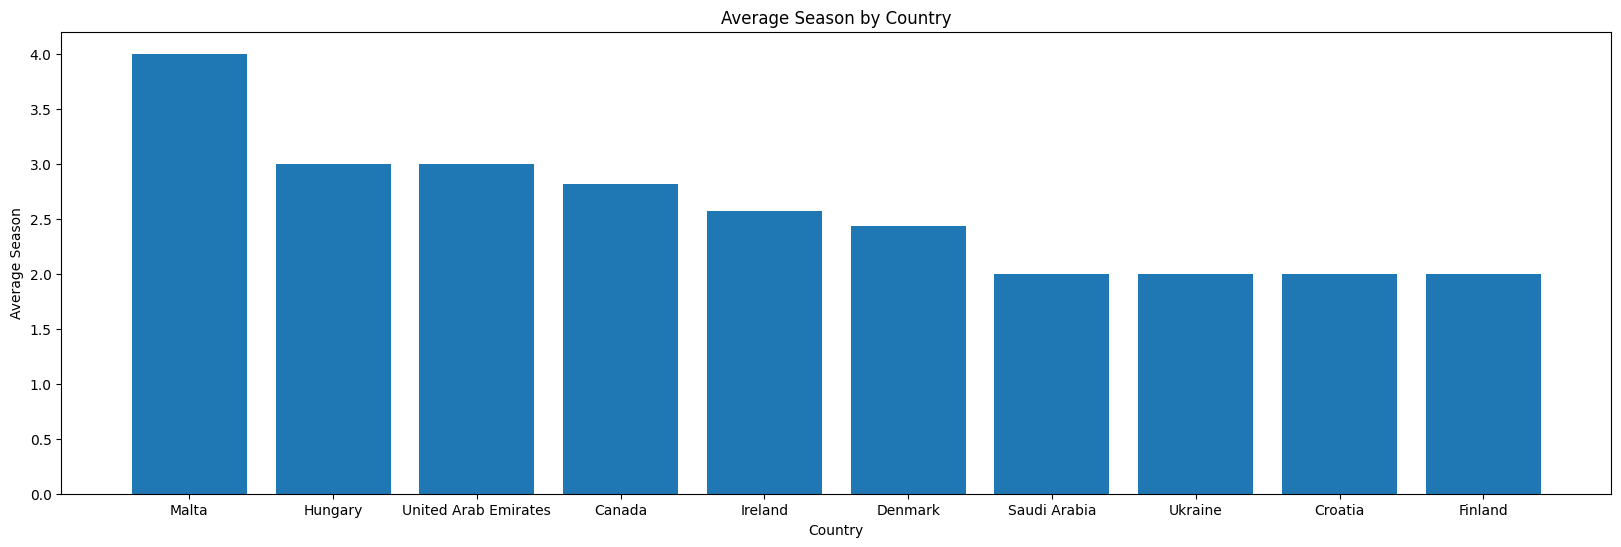

In [34]:
# implementation here
counts = df[df["type"] == "TV Show"].copy()
counts["duration"] = counts["duration"].str.split().str[0].astype(int)
counts["country"] = counts["country"].str.split(",")
counts = counts.explode("country")
counts["country"] = counts["country"].str.strip()
avg_season_by_country = counts.groupby("country")["duration"].mean().round(2)
avg_season_by_country = avg_season_by_country.sort_values(ascending=False).head(10)

plt.figure(figsize=(20, 6))
plt.bar(avg_season_by_country.index, avg_season_by_country.values)
plt.xlabel("Country")
plt.ylabel("Average Season")
plt.title("Average Season by Country")
plt.show()

It examines how the number of seasons in TV Shows varies across countries by using the duration information for TV Shows, calculating the average season count for each country, and comparing these values to identify which regions typically produce longer or shorter series.

### Q9. Genre Popularity Shift Over Years(5pts)

- How has the popularity of the most popular 3 genres changed over time?

Choose 3 most popular genres (check Q3) and analyze how often titles of each genre were added per year. This will require splitting the multi-genre column, filtering by the chosen genres, and grouping by year. Plot a multi-line chart to show the trend on these genres over years.

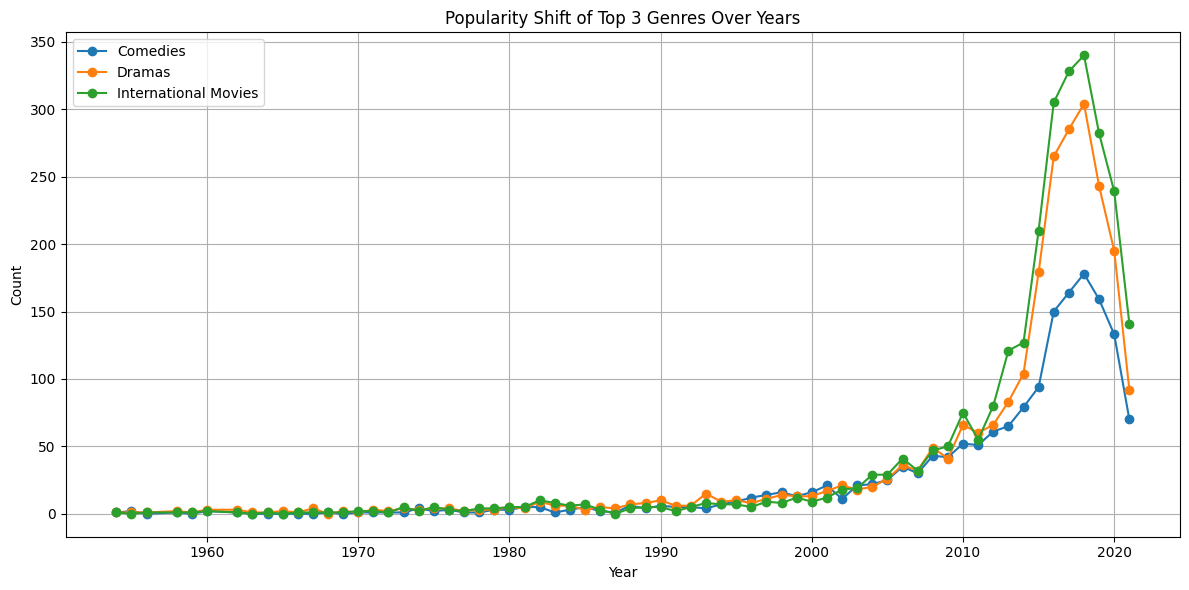

In [35]:
# implementation here
top_3_genre = df["listed_in"].str.split(",").explode().str.strip().value_counts().head(3).index

temp = df.copy()
temp["listed_in"] = temp["listed_in"].str.split(",")
temp = temp.explode("listed_in")
temp["listed_in"] = temp["listed_in"].str.strip()
temp = temp[temp["listed_in"].isin(top_3_genre)]

genre_year = temp.groupby(["release_year", "listed_in"]).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
for genre in genre_year.columns:
    plt.plot(genre_year.index, genre_year[genre], marker="o", label=genre)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Popularity Shift of Top 3 Genres Over Years")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It analyzes how genre popularity changes over time by splitting the listed_in column into individual genres, counting them for each year, and comparing these yearly trends to see which genres rise or decline in popularity.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw2.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.